# MC 06 — Runtime & Complexity Evidence

Compare computation only where standardized timing evidence exists. Missing runtime remains explicitly unavailable.

In [1]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "model_comparison.yaml"


In [2]:
import matplotlib.pyplot as plt
from src.ontario_peak_risk.model_comparison.io import load_config, load_model_reports
from src.ontario_peak_risk.model_comparison.runtime import runtime_table
from src.ontario_peak_risk.model_comparison.plotting import runtime_plot

config, project_root = load_config(CONFIG_PATH)
manual = config.get("runtime", {}).get("manual_overrides", {})

fc = runtime_table(
    load_model_reports(config, project_root, "forecasting"),
    manual.get("forecasting", {}),
)
pk = runtime_table(
    load_model_reports(config, project_root, "peak_risk"),
    manual.get("peak_risk", {}),
)

display(fc)
display(pk)


,model,family,runtime_seconds_evidence,runtime_minutes_evidence,runtime_source
0,Seasonal Naive,Baseline,NaN,NaN,unavailable
1,Random Forest Regressor,Bagging,NaN,NaN,unavailable
2,SARIMAX Rolling,Statistical Time Series,2223.858716,37.064312,runtime_diagnostics:sum(task_seconds)
3,XGBoost Regressor,Gradient Boosting,NaN,NaN,unavailable
4,LightGBM Regressor,Gradient Boosting,NaN,NaN,unavailable


,model,family,runtime_seconds_evidence,runtime_minutes_evidence,runtime_source
0,Logistic Regression,Baseline,NaN,NaN,unavailable
1,HistGradientBoosting,Gradient Boosting,NaN,NaN,unavailable
2,Random Forest Classifier,Bagging,1354.923875,22.582065,tuning_details:sum(task_seconds)
3,XGBoost Classifier,Gradient Boosting,113.649108,1.894152,tuning_details:sum(task_seconds)
4,LightGBM Classifier,Gradient Boosting,88.689420,1.478157,tuning_details:sum(task_seconds)


e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:307: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


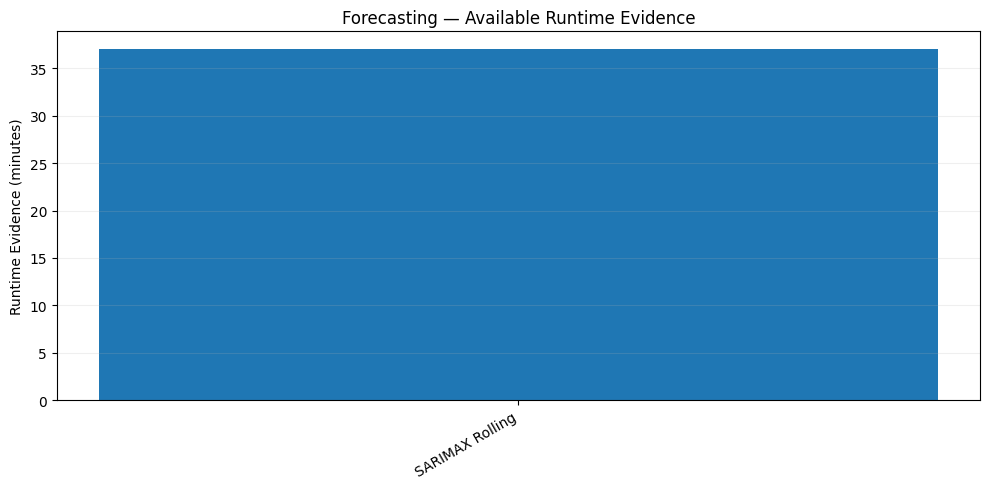

In [3]:
runtime_plot(fc, "Forecasting — Available Runtime Evidence"); plt.show()

e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:307: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


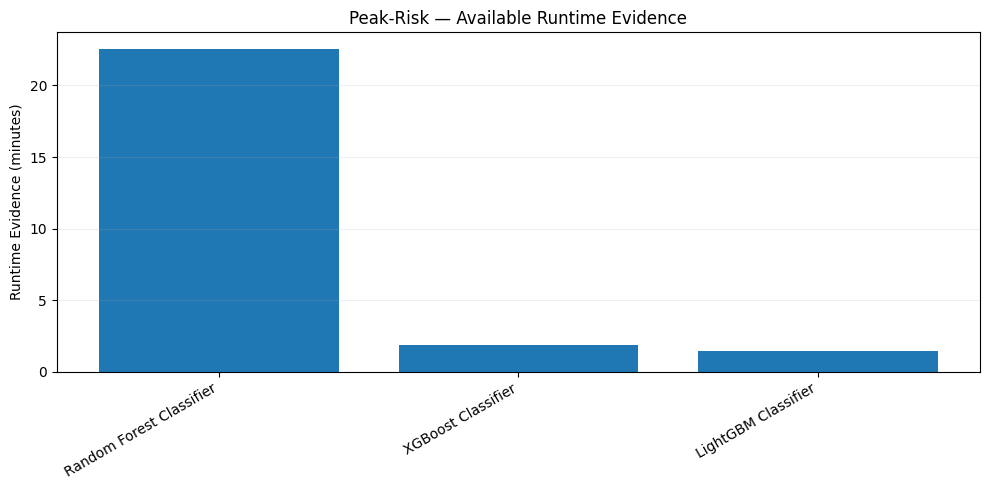

In [4]:
runtime_plot(pk, "Peak-Risk — Available Runtime Evidence"); plt.show()

Do not populate missing runtime values from memory. Only add a manual override when the runtime was recorded and can be documented.